# 0 SOBRE

## 0.1 DICIONÁRIO DE DADOS

* **customer_id**: Identificador único do cliente.
* **order_id**: Identificador único do pedido.
* **customer_age**: Idade do cliente.
* **customer_region**: Região geográfica do cliente.
* **customer_tenure_months**: Tempo de relacionamento do cliente com a
empresa (em meses).
* **order_value**: Valor total do pedido.
* **items_quantity**: Quantidade de itens no pedido.
* **discount_value**: Valor de desconto aplicado ao pedido.
* **payment_installments**: Número de parcelas do pagamento.
* **delivery_time_days**: Tempo total de entrega (em dias).
* **delivery_delay_days**: Quantidade de dias de atraso na entrega.
* **freight_value**: Valor do frete.
* **delivery_attempts**: Número de tentativas de entrega.
* **customer_service_contacts**: Número de contatos do cliente com o
atendimento.
* **resolution_time_days**: Tempo para resolução de problemas (em dias).
* **complaints_count**: Número de reclamações registradas pelo cliente.
* **repeat_purchase_30d**: Indica se houve recompra em até 30 dias após o
pedido (0 = não, 1 = sim).
* **csat_internal_score**: Score interno de satisfação do cliente.
* **nps_score**: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.

## 0.2 PERGUNTAS NORTEADORAS

* Quais fatores parecem mais críticos para a satisfação?
* O que mais gera detratores?
* Existe algum “ponto de ruptura” na experiência do cliente?
* Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

# 1 CONFIGURAÇÃO E IMPORTAÇÃO

In [ ]:
# Manipulação de Dados

import pandas as pd
import numpy as np

# Gráficos

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configurações

import warnings
warnings.filterwarnings("ignore")

# 2 CARGA E INSPEÇÃO INICIAL

- Qual a quantidade de linhas e colunas do dataset?
- Quais os tipos das colunas?



In [ ]:
# Leitura d Arquivo .csv

df_nps = pd.read_csv('desafio_nps_fase_1.csv')

In [ ]:
# Quantidade de linhas e Colunas  no Dataset

print(f"Número de linhas: {df_nps.shape[0]}")
print(f"Número de colunas: {df_nps.shape[1]}")

Número de linhas: 2500
Número de colunas: 19


In [ ]:
# Mostrar algumas linhas do dataset

df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
# Mostrando o tipo de dado de cada coluna no dataset

df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

# 3 QUALIDADE DOS DADOS (LIMPEZA INICIAL)

In [ ]:
# Verificando se existem registros nulos

print(f"Quantidade de valores nulos: {df_nps.isnull().sum().sum()}")

Quantidade de valores nulos: 0


In [ ]:
# Quantidade de valores duplicados

print(f"Quantidade de valores duplicados: {df_nps.duplicated().sum()}")

Quantidade de valores duplicados: 0


## 3.1 VALIDAÇÃO DE REGRAS DE NEGÓCIO E ANOMALIAS

In [ ]:
# Count, média, desvio padrão, min e percentis das colunas de valores.

df_nps[['customer_age','customer_tenure_months','order_value','items_quantity','discount_value',
        'payment_installments','delivery_time_days','delivery_delay_days','freight_value',
        'delivery_attempts','customer_service_contacts','resolution_time_days','nps_score','repeat_purchase_30d','complaints_count',
        'csat_internal_score']].describe().round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [ ]:
# Valor mínimo e valor máxixo de cada coluna de valores

df_nps[['customer_age','customer_tenure_months','order_value','items_quantity','discount_value',
        'payment_installments','delivery_time_days','delivery_delay_days','freight_value',
        'delivery_attempts','customer_service_contacts','resolution_time_days','nps_score','repeat_purchase_30d','complaints_count',
        'csat_internal_score']].agg(['min','max']).round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
min,18,1,7.76,1,0.02,1,2,0,2.62,1,0,0,0.0,0,0,0.0
max,69,119,1983.81,6,230.33,11,14,8,76.13,3,7,11,10.0,1,11,10.0


### 3.1.1 customer_age

In [ ]:
df_nps['customer_age'].describe()

count    2500.000000
mean       43.396000
std        14.888487
min        18.000000
25%        31.000000
50%        43.000000
75%        56.000000
max        69.000000
Name: customer_age, dtype: float64

In [ ]:
customer_age_validate = df_nps[df_nps["customer_age"] < 5]
print(f"Quantidade de customer com idade menor de 5 anos: {customer_age_validate.shape[0]}")

customer_age_validate = df_nps[df_nps["customer_age"] > 100]
print(f"Quantidade de customer com idade maior de 100 anos: {customer_age_validate.shape[0]}")

Quantidade de customer com idade menor de 5 anos: 0
Quantidade de customer com idade maior de 100 anos: 0


### 3.1.2 customer_tenure_months

In [ ]:
df_nps['customer_tenure_months'].describe()

count    2500.000000
mean       61.322400
std        34.478729
min         1.000000
25%        31.000000
50%        62.000000
75%        91.000000
max       119.000000
Name: customer_tenure_months, dtype: float64

In [ ]:
customer_tenure_months_validate = df_nps[df_nps["customer_tenure_months"] < 0]
print(f"Quantidade de customer tenure months menor de 0 meses: {customer_tenure_months_validate.shape[0]}")

Quantidade de customer tenure months menor de 0 meses: 0


### 3.1.3 order_value

In [ ]:
df_nps['order_value'].describe()

count    2500.000000
mean      434.259740
std       289.772497
min         7.760000
25%       220.245000
50%       375.515000
75%       577.290000
max      1983.810000
Name: order_value, dtype: float64

In [ ]:
order_value_validate = df_nps[df_nps["order_value"] < 0]
print(f"Quantidade de pedidos com order_value menor 0: {order_value_validate.shape[0]}")

Quantidade de pedidos com order_value menor 0: 0


### 3.1.4 items_quantity

In [ ]:
df_nps['items_quantity'].describe()

count    2500.000000
mean        3.470800
std         1.687331
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max         6.000000
Name: items_quantity, dtype: float64

In [ ]:
items_quantity_validate = df_nps[df_nps["items_quantity"] <= 0]
print(f"Quantidade de pedidos sem itens: {items_quantity_validate.shape[0]}")

Quantidade de pedidos sem itens: 0


### 3.1.5 discount_value

Encontramos percentual de desconto maior que o o valor da compra

In [ ]:
df_nps['discount_value'].describe()

count    2500.000000
mean       29.745620
std        29.225603
min         0.020000
25%         8.885000
50%        20.935000
75%        40.832500
max       230.330000
Name: discount_value, dtype: float64

In [ ]:
discount_value_validate = df_nps[df_nps["discount_value"] > df_nps["order_value"]]
print(f"Quantidade de pedidos com desconto maior que o valor: {discount_value_validate.shape[0]}")

Quantidade de pedidos com desconto maior que o valor: 35


In [ ]:
discount_value_validate.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
57,58,54,Sul,101,50058,86.15,2,112.42,11,10,3,36.23,3,1,0,8.4,1,2,5.5
116,117,28,Centro-Oeste,38,50117,60.96,2,95.06,4,9,0,30.19,2,0,7,7.8,0,1,5.2
182,183,41,Sudeste,104,50183,24.00,6,85.49,10,5,2,29.58,3,0,9,4.0,0,4,1.4
270,271,59,Nordeste,80,50271,79.93,2,129.11,6,2,4,27.59,1,1,1,1.1,0,3,4.8


### 3.1.6 payment_installments:

In [ ]:
df_nps['payment_installments'].describe()

count    2500.000000
mean        6.004000
std         3.159743
min         1.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        11.000000
Name: payment_installments, dtype: float64

In [ ]:
payment_installments_validate = df_nps[df_nps["payment_installments"] <= 0]
print(f"Quantidade de pedidos com o número de parcelas abaixo ou igual a zero: {payment_installments_validate.shape[0]}")

Quantidade de pedidos com o número de parcelas abaixo ou igual a zero: 0


### 3.1.7 delivery_time_days

In [ ]:
df_nps['delivery_time_days'].describe()

count    2500.000000
mean        8.022000
std         3.770411
min         2.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        14.000000
Name: delivery_time_days, dtype: float64

In [ ]:
delivery_time_days_validate = df_nps[df_nps["delivery_time_days"] <= 0]
print(f"Quantidade de pedidos com o número de dias para entrega menor de zero: {delivery_time_days_validate.shape[0]}")

Quantidade de pedidos com o número de dias para entrega menor de zero: 0


### 3.1.8 delivery_delay_days

In [ ]:
df_nps['delivery_delay_days'].describe()

count    2500.000000
mean        2.187200
std         1.454442
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: delivery_delay_days, dtype: float64

In [ ]:
delivery_delay_days_validate = df_nps[df_nps["delivery_delay_days"] < 0]
print(f"Quantidade de pedidos com o número de dias para entrega atrasados menor de zero: {delivery_delay_days_validate.shape[0]}")

delivery_delay_days_validate = df_nps[df_nps["delivery_delay_days"] >= df_nps["delivery_time_days"] ]
print(f"Quantidade de pedidos com o número de dias atrasado maior que a quantidade de dias para ser entregue: {delivery_delay_days_validate.shape[0]}")

Quantidade de pedidos com o número de dias para entrega atrasados menor de zero: 0
Quantidade de pedidos com o número de dias atrasado maior que a quantidade de dias para ser entregue: 267


###  3.1.9 freight_value

In [ ]:
df_nps['freight_value'].describe()

count    2500.000000
mean       38.217016
std        12.076074
min         2.620000
25%        29.927500
50%        38.500000
75%        46.270000
max        76.130000
Name: freight_value, dtype: float64

In [ ]:
freight_value_validate = df_nps[df_nps["freight_value"] < 0]
print(f"Quantidade de pedidos com valor de frete menor de zero: {freight_value_validate.shape[0]}")

Quantidade de pedidos com valor de frete menor de zero: 0


### 3.1.10 delivery_attempts

In [ ]:
df_nps['delivery_attempts'].describe()
# Pode ter relação com o atrasado da entrega e com a quantidade de itens no pedido

count    2500.000000
mean        2.005600
std         0.815497
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: delivery_attempts, dtype: float64

In [ ]:
delivery_attempts_validate = df_nps[df_nps["delivery_attempts"] < 0]
print(f"Quantidade de pedidos sem tentativa de entraga: {delivery_attempts_validate.shape[0]}")

Quantidade de pedidos sem tentativa de entraga: 0


### 3.1.11 customer_service_contacts

In [ ]:
df_nps['customer_service_contacts'].describe()
# Se customer_service_contacts for considerando o histórico todo

count    2500.000000
mean        1.519600
std         1.231512
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: customer_service_contacts, dtype: float64

In [ ]:
customer_service_contacts_validate = df_nps[df_nps["customer_service_contacts"] < 0]
print(f"Quantidade valores menores de 0: {customer_service_contacts_validate.shape[0]}")

Quantidade valores menores de 0: 0


### 3.1.12 resolution_time_days

In [ ]:
df_nps['resolution_time_days'].describe()

count    2500.000000
mean        5.485600
std         3.458002
min         0.000000
25%         2.000000
50%         6.000000
75%         8.000000
max        11.000000
Name: resolution_time_days, dtype: float64

In [ ]:
resolution_time_days_validate = df_nps[df_nps["resolution_time_days"] < 0]
print(f"Quantidade valores menores de 0: {resolution_time_days_validate.shape[0]}")

resolution_time_days_validate = df_nps[(df_nps["resolution_time_days"] > 0) & (df_nps['customer_service_contacts'] == 0)]
print(f"Quantidade de registros com tempo de resolução > 0 e contatos de serviço do cliente = 0: {resolution_time_days_validate.shape[0]}")

Quantidade valores menores de 0: 0
Quantidade de registros com tempo de resolução > 0 e contatos de serviço do cliente = 0: 511


### 3.1.13 complaints_count

In [ ]:
df_nps['complaints_count'].describe()

count    2500.000000
mean        4.150400
std         1.784223
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        11.000000
Name: complaints_count, dtype: float64

In [ ]:
complaints_count_validate = df_nps[df_nps["complaints_count"] < 0]
print(f"Quantidade valores menores de 0: {complaints_count_validate.shape[0]}")


complaints_count_validate = df_nps[(df_nps["complaints_count"] > 0) & (df_nps['customer_service_contacts'] == 0)]
print(f"Quantidade de registros com tempo de resolução > 0 e reclamaçoes do cliente = 0: {resolution_time_days_validate.shape[0]}")

Quantidade valores menores de 0: 0
Quantidade de registros com tempo de resolução > 0 e reclamaçoes do cliente = 0: 511


### 3.1.14 repeat_purchase_30d

In [ ]:
df_nps['repeat_purchase_30d'].describe()

count    2500.000000
mean        0.087200
std         0.282184
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: repeat_purchase_30d, dtype: float64

In [ ]:
repeat_purchase_30d_validate = df_nps[df_nps["repeat_purchase_30d"] < 0]
print(f"Quantidade valores menores de 0: {repeat_purchase_30d_validate.shape[0]}")

repeat_purchase_30d_validate = df_nps[df_nps["repeat_purchase_30d"] > 1]
print(f"Quantidade valores maiores de 1: {repeat_purchase_30d_validate.shape[0]}")

Quantidade valores menores de 0: 0
Quantidade valores maiores de 1: 0


### 3.1.15 csat_internal_score

In [ ]:
df_nps['csat_internal_score'].describe()

count    2500.000000
mean        2.941600
std         2.378957
min         0.000000
25%         0.700000
50%         2.800000
75%         4.800000
max        10.000000
Name: csat_internal_score, dtype: float64

In [ ]:
csat_internal_score_validate = df_nps[df_nps["csat_internal_score"] < 0]
print(f"Quantidade valores manores de 0: {csat_internal_score_validate.shape[0]}")

csat_internal_score_validate = df_nps[df_nps["csat_internal_score"] > 10]
print(f"Quantidade valores maiores de 10: {csat_internal_score_validate.shape[0]}")

Quantidade valores manores de 0: 0
Quantidade valores maiores de 10: 0


### 3.1.16 nps_score

In [ ]:
df_nps['nps_score'].describe()

count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps_score, dtype: float64

In [ ]:
nps_score_validate = df_nps[df_nps["nps_score"] < 0]
print(f"Quantidade valores manores de 0: {nps_score_validate.shape[0]}")

nps_score_validate = df_nps[df_nps["nps_score"] > 10]
print(f"Quantidade valores maiores de 10: {nps_score_validate.shape[0]}")

Quantidade valores manores de 0: 0
Quantidade valores maiores de 10: 0


In [ ]:
# Arredondado o NPS
df_nps['nps_score']= df_nps['nps_score'].round(0)

## 3.2 NOVAS COLUNAS

### 3.2.1 Classificação NPS
* (Notas 9 e 10): Clientes extremamente satisfeitos que divulgam a marca e geram crescimento orgânico: Promotor.
* (Notas 7 e 8): Clientes apenas satisfeitos, mas que não são leais e podem migrar facilmente para a concorrência: Neutro.
* (Notas 0 a 6): Clientes insatisfeitos que tiveram experiências ruins e podem prejudicar a reputação da empresa: Detrator.

In [ ]:
conditions = [
    (df_nps['nps_score'].round(0) >= 9),
    (df_nps['nps_score'].round(0) >= 7) & (df_nps['nps_score'].round(0) <= 8),
    (df_nps['nps_score'].round(0) >= 0) & (df_nps['nps_score'].round(0) <= 6)
]

choices = ['Promotor', 'Neutro', 'Detrator']
df_nps['nps_classification'] = np.select(conditions, choices, default='Não Classificado')

In [ ]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_classification
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,7.0,0,3,6.5,Neutro
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.0,0,3,0.0,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,5.0,0,7,1.5,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,6.0,0,4,0.3,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.0,0,3,7.9,Detrator


### 3.2.2 Discount Percent

In [ ]:
df_nps['discount_percent'] = (df_nps['discount_value'] / df_nps['order_value']).round(2)
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_classification,discount_percent
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,7.0,0,3,6.5,Neutro,0.28
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.0,0,3,0.0,Detrator,0.02
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,5.0,0,7,1.5,Detrator,0.08
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,6.0,0,4,0.3,Detrator,0.06
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.0,0,3,7.9,Detrator,0.12


### 3.2.3 Teve Atrasado  

In [ ]:
df_nps['had_delay_days'] = (df_nps['delivery_delay_days'] > 0)
df_nps[['delivery_delay_days','had_delay_days']].tail()

df_nps[['delivery_delay_days','had_delay_days']].groupby(by='had_delay_days').count()

,delivery_delay_days
had_delay_days,
False,277
True,2223


### 3.2.4 Teve Desconto

In [ ]:
df_nps['had_discount'] = (df_nps['discount_percent'] > 0)
df_nps[['discount_percent','had_discount']].tail()

df_nps[['delivery_delay_days','had_discount']].groupby(by='had_discount').count()

,delivery_delay_days
had_discount,
False,182
True,2318


In [ ]:
df_nps['discount_percent'].describe()

count    2500.000000
mean        0.125192
std         0.254153
min         0.000000
25%         0.020000
50%         0.060000
75%         0.130000
max         3.760000
Name: discount_percent, dtype: float64

# 4 ANALISES

## 4.1 NPS Geral

In [ ]:
# Mediana, média, mínimo e máximo do NPS Score
df_nps[['nps_score']].agg(['median','mean','min','max'])

,nps_score
median,4.0000
mean,4.3772
min,0.0000
max,10.0000


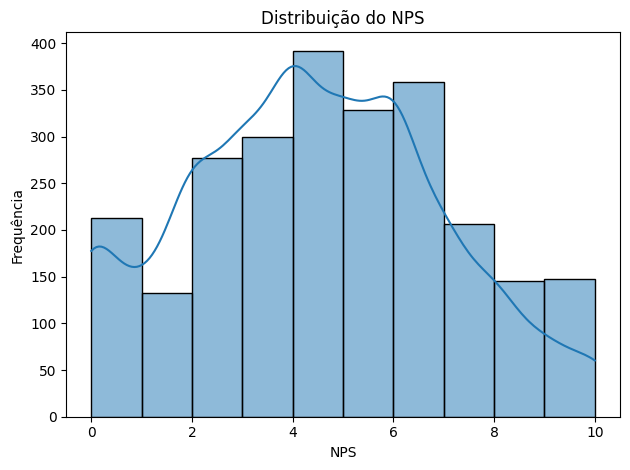

In [ ]:
# Distribuição do NPS (Histograma)
sns.histplot(df_nps['nps_score'], bins=10,kde=True)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

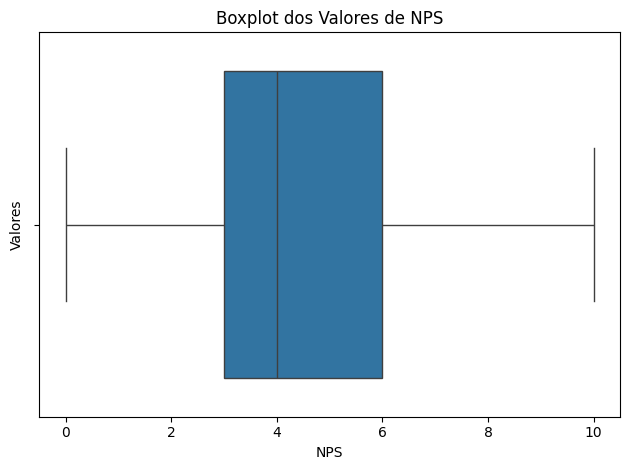

In [ ]:
# Boxplot do NPOS
sns.boxplot(x=df_nps['nps_score'], data=df_nps)

# Adicionar título e rótulos dos eixos
plt.title('Boxplot dos Valores de NPS')
plt.xlabel('NPS')
plt.ylabel('Valores')
plt.tight_layout()
plt.show()

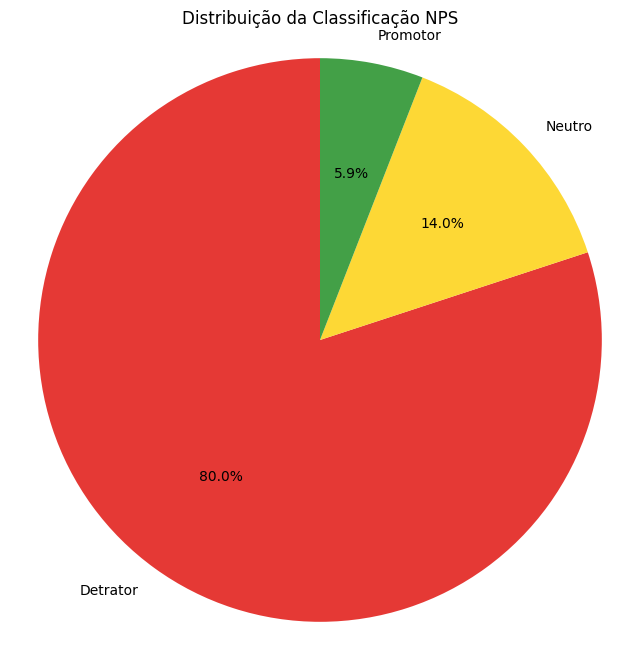

In [ ]:
# Classificação do NPS

nps_classification_counts = df_nps['nps_classification'].value_counts()

# Mapeamento de cores

color_map = {
    "Detrator": "#E53935",  # Vermelho
    "Neutro": "#FDD835",    # Amarelo
    "Promotor": "#43A047"   # Verde
}

# Lista de cores na mesma ordem dos índices

colors = [color_map[categoria] for categoria in nps_classification_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(
    nps_classification_counts,
    labels=nps_classification_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Distribuição da Classificação NPS')
plt.axis('equal')
plt.show()

In [ ]:
# Nps médio por região

df_nps_regiao = pd.DataFrame(df_nps.groupby('customer_region')[['nps_score']].mean().round(2)).reset_index()

df_nps_regiao.head()

,customer_region,nps_score
0,Centro-Oeste,4.20
1,Nordeste,4.44
2,Norte,4.38
3,Sudeste,4.38
4,Sul,4.47


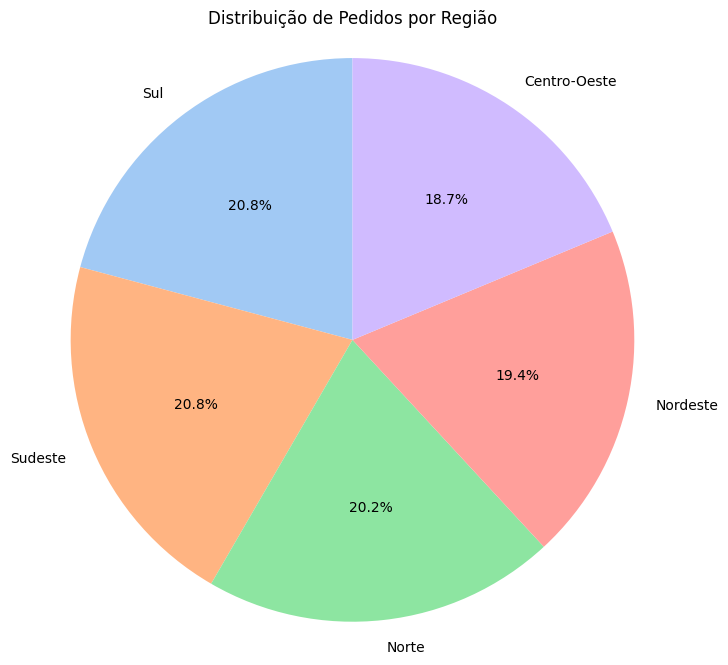

In [ ]:
# Classificação do NPS

nps_classification_counts = df_nps['customer_region'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    nps_classification_counts,
    labels=nps_classification_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Distribuição de Pedidos por Região')
plt.axis('equal')
plt.show()

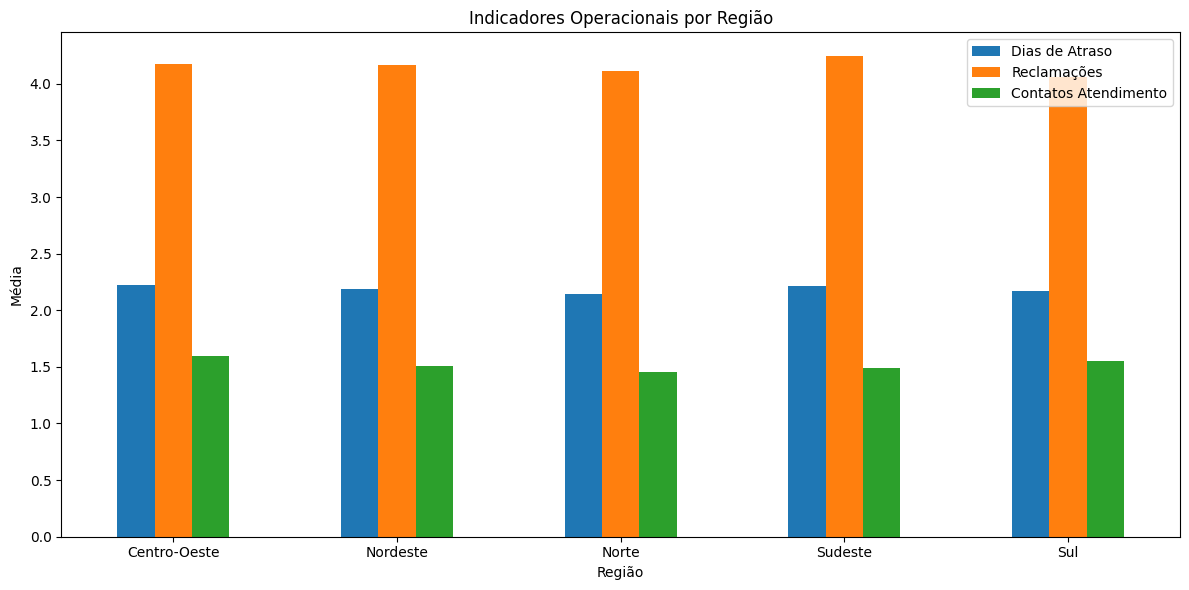

In [ ]:
# Visualização de indicadores operacionais por região

comparacao = (
    df_nps.groupby("customer_region")[
        [
            "delivery_delay_days",
            "complaints_count",
            "customer_service_contacts"
        ]
    ]
    .mean()
)

comparacao.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Indicadores Operacionais por Região"
)

plt.xlabel("Região")
plt.ylabel("Média")
plt.xticks(rotation=0)

plt.legend([
    "Dias de Atraso",
    "Reclamações",
    "Contatos Atendimento"
])

plt.tight_layout()
plt.show()

## 4.2 NPS vs Repurchase

In [ ]:
# NPS médio com repeat_purchase vs sem repeat_purschase. 
# A repurchase não é causa, é consequencia. NPS baixo = não compra novamente.

df_nps_repeat_purchase = pd.DataFrame(df_nps.groupby('repeat_purchase_30d')[['nps_score']].mean().round(2)).reset_index()
df_nps_repeat_purchase.head()

,repeat_purchase_30d,nps_score
0,0,3.94
1,1,8.98


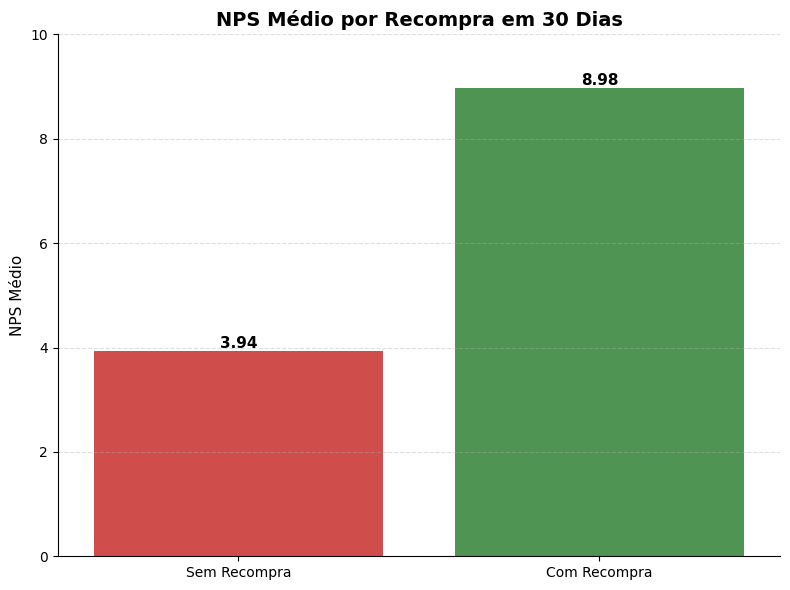

In [ ]:
# NPS médio com repeat_purchase vs sem repeat_purschase.

df_nps_repeat_purchase['repeat_purchase_label'] = (
    df_nps_repeat_purchase['repeat_purchase_30d']
    .map({
        0: 'Sem Recompra',
        1: 'Com Recompra'
    })
)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='repeat_purchase_label',
    y='nps_score',
    data=df_nps_repeat_purchase,
    estimator='mean',
    errorbar=None,
    palette=[
        '#E53935',  # Vermelho
        '#43A047'   # Verde
    ]
)

# Adiciona os valores nas barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'NPS Médio por Recompra em 30 Dias',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('NPS Médio', fontsize=11)

plt.ylim(0, 10)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

sns.despine()

plt.tight_layout()
plt.show()


## 4.3 NPS vs Teve Atrasado na Entrega

In [ ]:
#Fitro
df_nps_delivery_delay_days = pd.DataFrame(df_nps.groupby('had_delay_days')[['nps_score']].mean().round(2)).reset_index()
df_nps_delivery_delay_days.head()

,had_delay_days,nps_score
0,False,6.87
1,True,4.07


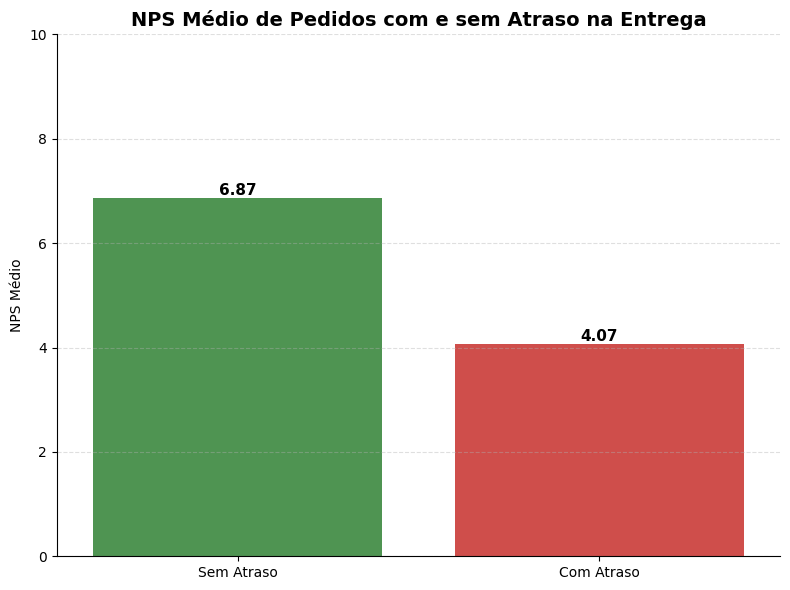

In [ ]:
# NPS médio de pedidos com e sem atraso na entrega

# Cria rótulos mais amigáveis
df_nps_delivery_delay_days['delay_label'] = (
    df_nps_delivery_delay_days['had_delay_days']
    .map({
        False: 'Sem Atraso',
        True: 'Com Atraso'
    })
)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='delay_label',
    y='nps_score',
    data=df_nps_delivery_delay_days,
    estimator='mean',
    errorbar=None,
    hue='delay_label',
    palette={
        'Sem Atraso': '#43A047',  # Verde
        'Com Atraso': '#E53935'   # Vermelho
    },
    legend=False
)

# Adiciona os valores nas barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'NPS Médio de Pedidos com e sem Atraso na Entrega',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('NPS Médio')

plt.ylim(0, 10)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

sns.despine()

plt.tight_layout()
plt.show()

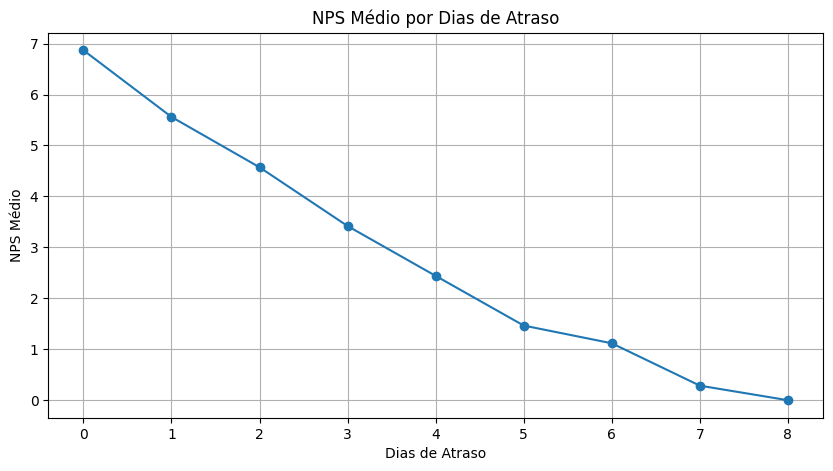

In [ ]:
# NPS médio por dias de atraso na entrega

df_plot = (
    df_nps.groupby('delivery_delay_days')['nps_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(
    df_plot['delivery_delay_days'],
    df_plot['nps_score'],
    marker='o'
)

plt.title('NPS Médio por Dias de Atraso')
plt.xlabel('Dias de Atraso')
plt.ylabel('NPS Médio')
plt.grid(True)
plt.show()

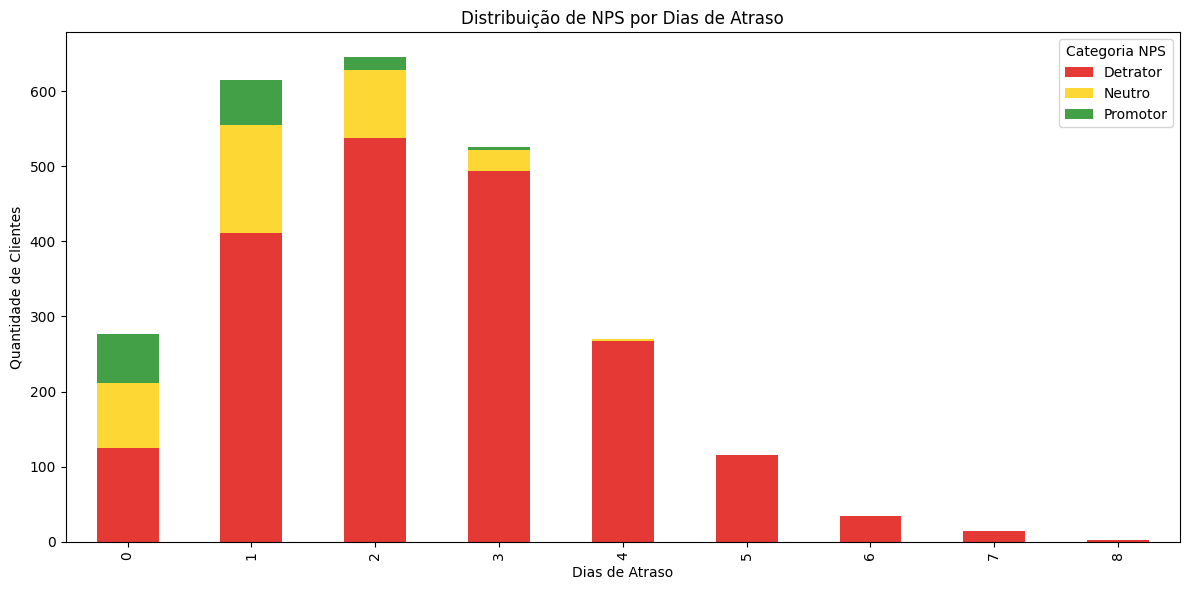

In [ ]:
# NPS médio por dias de atraso na entrega (com barras)

# Agrupamento
tabela = (
    df_nps.groupby(["delivery_delay_days", "nps_classification"])
      .size()
      .unstack(fill_value=0)
)

# Garantir ordem das colunas
tabela = tabela[["Detrator", "Neutro", "Promotor"]]

# Cores por categoria
cores = ["#E53935",  # Detrator (vermelho)
         "#FDD835",  # Neutro (amarelo)
         "#43A047"]  # Promotor (verde)

# Gráfico
ax = tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=cores
)

plt.title("Distribuição de NPS por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("Quantidade de Clientes")
plt.legend(title="Categoria NPS")

plt.tight_layout()
plt.show()

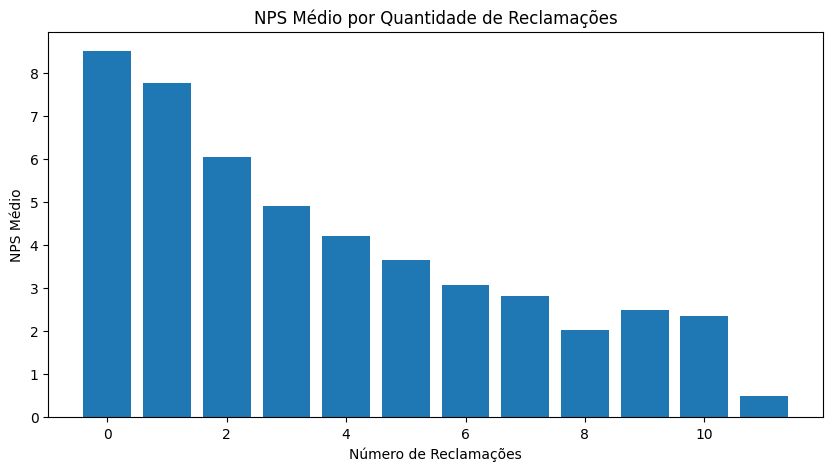

In [ ]:
# NPS médio por quantidade de reclamações


df_plot = (
    df_nps.groupby('complaints_count')['nps_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(
    df_plot['complaints_count'],
    df_plot['nps_score']
)

plt.title('NPS Médio por Quantidade de Reclamações')
plt.xlabel('Número de Reclamações')
plt.ylabel('NPS Médio')
plt.show()

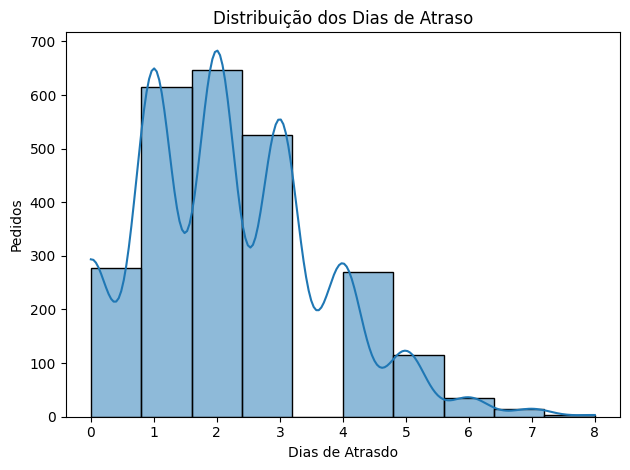

In [ ]:
# Distribuição do NPS (Histograma)
sns.histplot(df_nps['delivery_delay_days'], bins=10,kde=True)
plt.title('Distribuição dos Dias de Atraso')
plt.xlabel('Dias de Atrasdo')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.show()

## 4.4 Correlações Variáveis Númericas (heatmap)

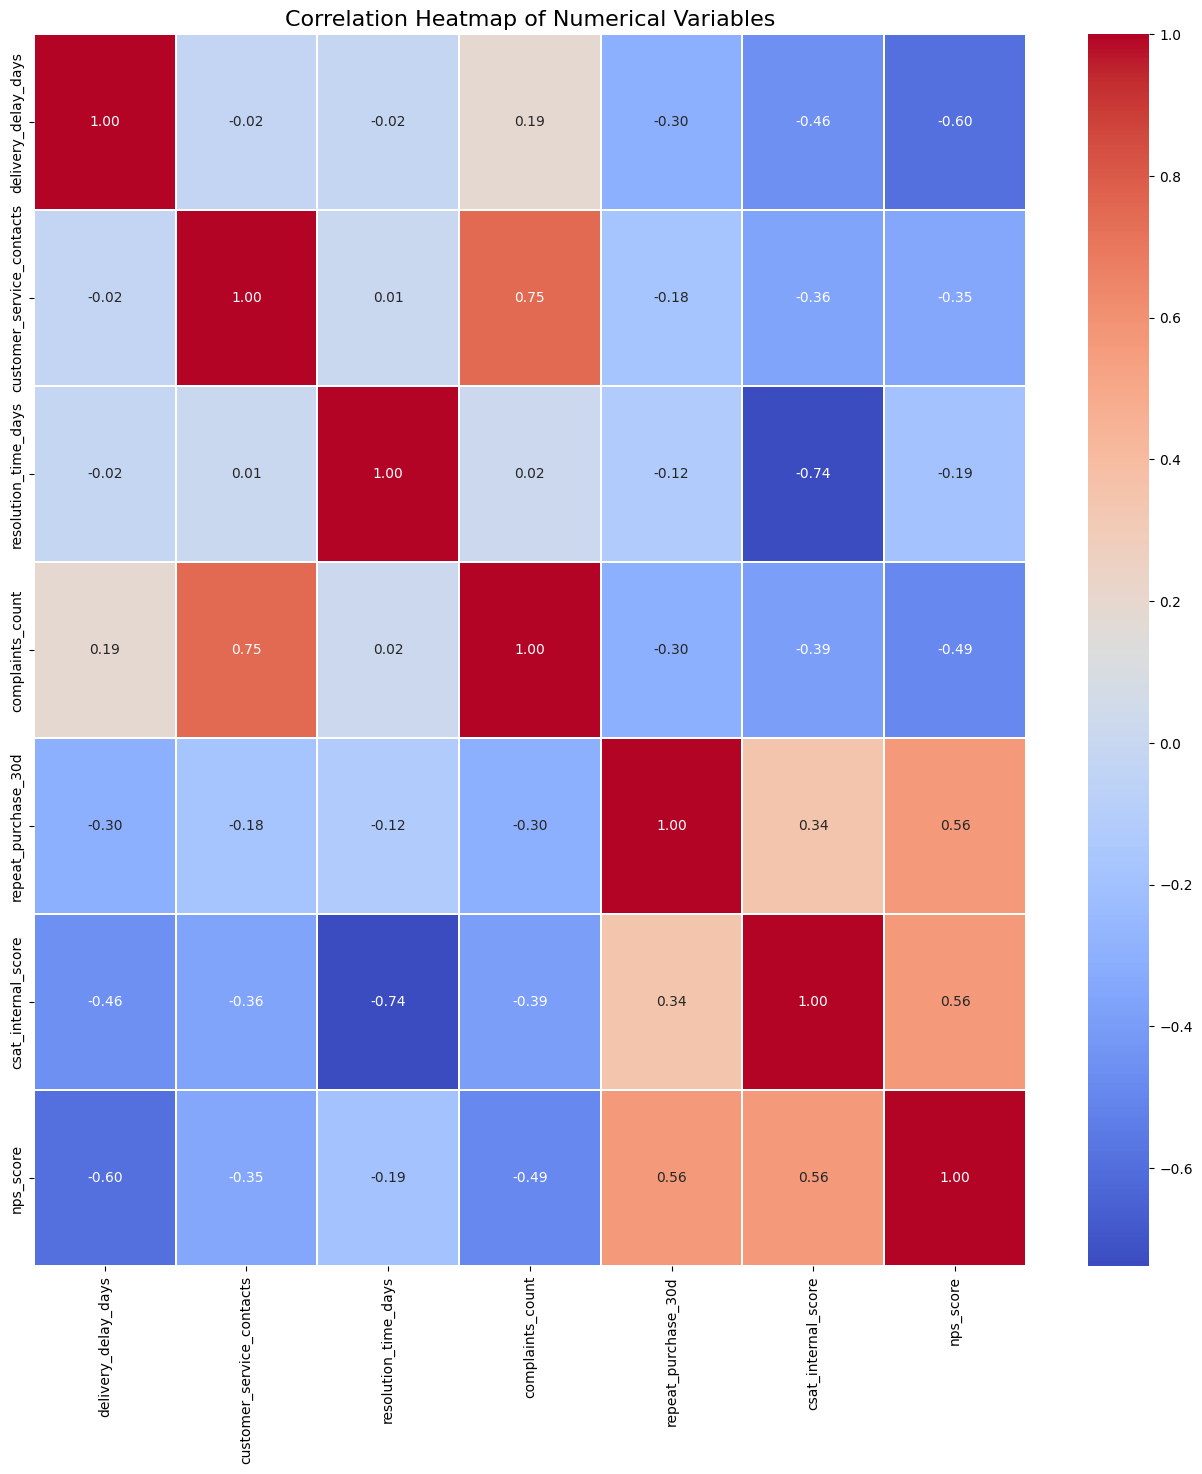

In [ ]:
numerical_df = df_nps[['delivery_delay_days',
                       'customer_service_contacts', 'resolution_time_days', 'complaints_count',
                       'repeat_purchase_30d', 'csat_internal_score', 'nps_score']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(16, 16))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.1)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

##

- Segundo o heatmap acima, as principais variáveis que impactam um baixo valor de NPS são: delivery_delay_days e complaints_count.
- Um NPS alto, implica em um repeat_purchase e em um csat_internal_score também alto.

# 5. CONCLUSÕES

## 5.1 Quais fatores parecem mais críticos para a satisfação?

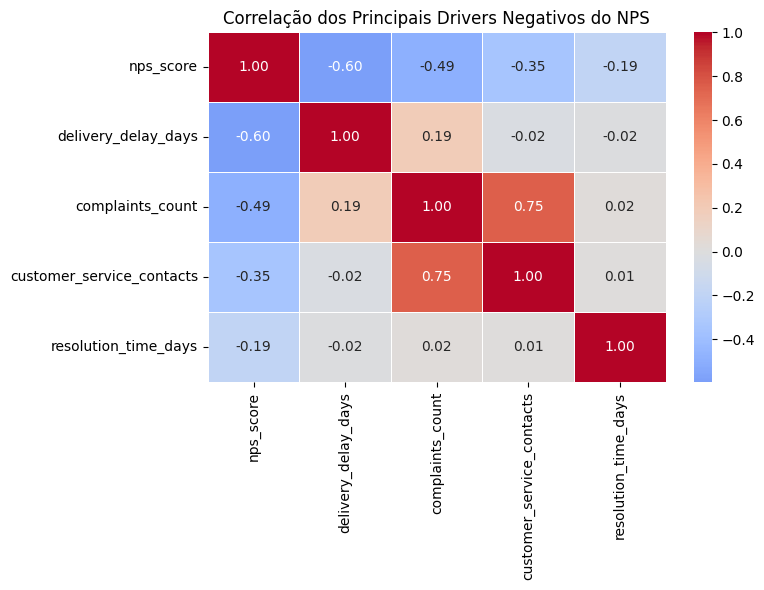

In [ ]:
# Selecionando as colunas de interesse para análise de correlação

cols = [
    'nps_score',
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]

# Matriz de correlação
corr = df_nps[cols].corr()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlação dos Principais Drivers Negativos do NPS')
plt.tight_layout()
plt.show()

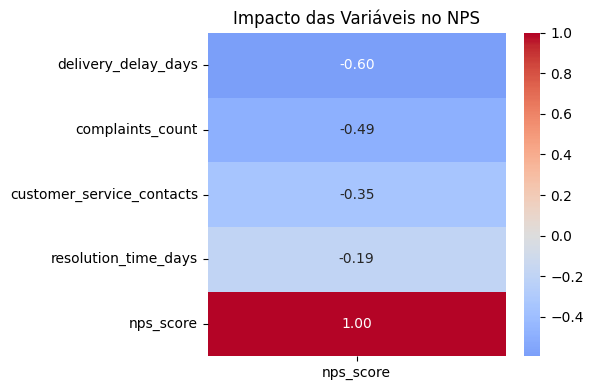

In [ ]:
# Analisando a correlação entre as variáveis e o NPS

variaveis = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]

corr_nps = (
    df_nps[variaveis + ['nps_score']]
    .corr()[['nps_score']]
    .sort_values('nps_score')
)

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_nps,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Impacto das Variáveis no NPS')
plt.tight_layout()
plt.show()

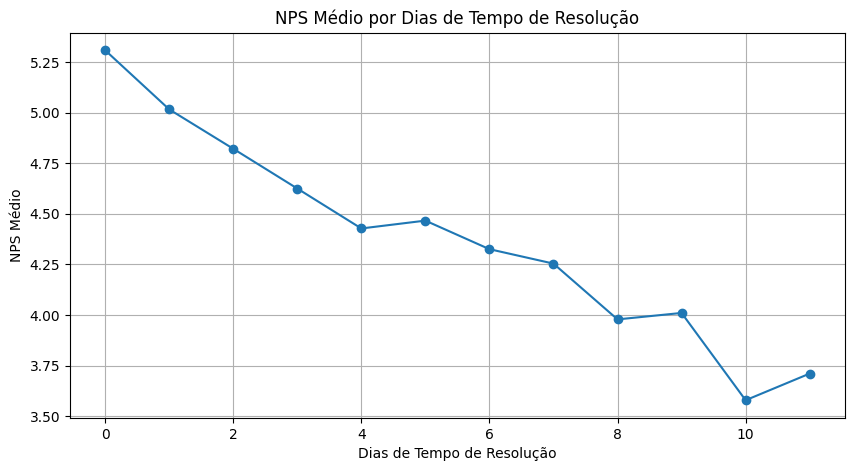

In [ ]:
# NPS médio por dias de atraso na entrega

df_plot_resolution = df_nps.groupby('resolution_time_days')['nps_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(
    df_plot_resolution['resolution_time_days'],
    df_plot_resolution['nps_score'],
    marker='o'
)

plt.title('NPS Médio por Dias de Tempo de Resolução')
plt.xlabel('Dias de Tempo de Resolução')
plt.ylabel('NPS Médio')
plt.grid(True)
plt.show()

## 5.2 O que mais gera detratores?

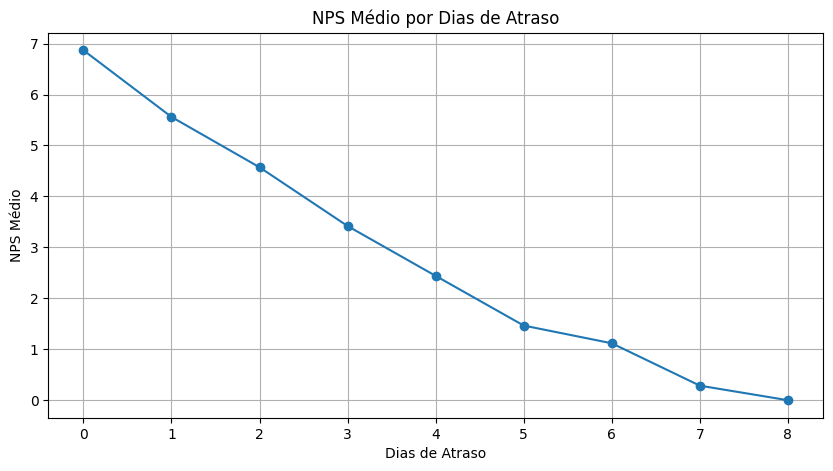

In [ ]:
# NPS médio por dias de atraso na entrega

df_plot = (
    df_nps.groupby('delivery_delay_days')['nps_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(
    df_plot['delivery_delay_days'],
    df_plot['nps_score'],
    marker='o'
)

plt.title('NPS Médio por Dias de Atraso')
plt.xlabel('Dias de Atraso')
plt.ylabel('NPS Médio')
plt.grid(True)
plt.show()

## 5.3 Existe algum “ponto de ruptura” na experiência do cliente?


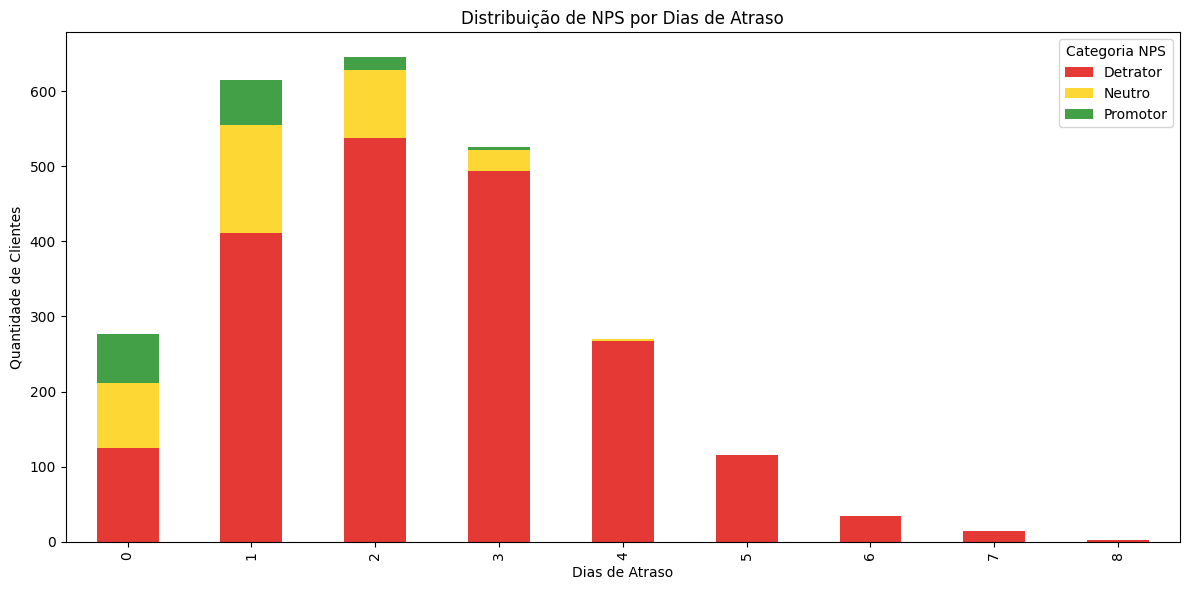

In [ ]:
# NPS médio por dias de atraso na entrega (com barras)

# Agrupamento
tabela = (
    df_nps.groupby(["delivery_delay_days", "nps_classification"])
      .size()
      .unstack(fill_value=0)
)

# Garantir ordem das colunas
tabela = tabela[["Detrator", "Neutro", "Promotor"]]

# Cores por categoria
cores = ["#E53935",  # Detrator (vermelho)
         "#FDD835",  # Neutro (amarelo)
         "#43A047"]  # Promotor (verde)

# Gráfico
ax = tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=cores
)

plt.title("Distribuição de NPS por Dias de Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("Quantidade de Clientes")
plt.legend(title="Categoria NPS")

plt.tight_layout()
plt.show()

## 5.4  Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

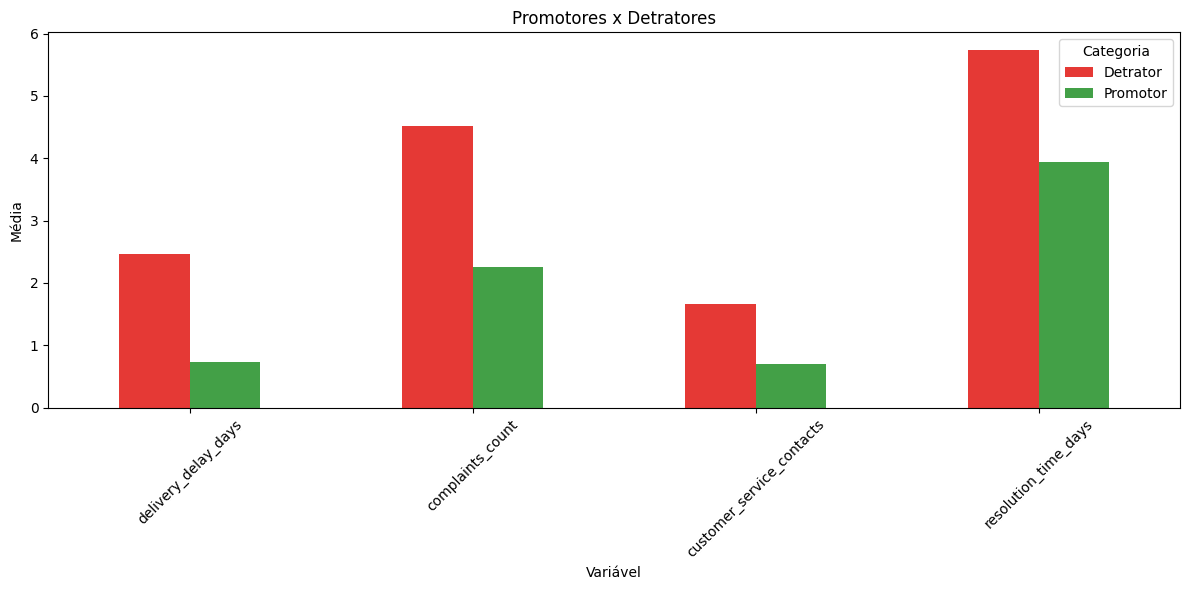

In [ ]:
# NPS médio por quantidade de reclamações

variaveis = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]

# Garantir ordem das colunas
tabela = tabela[["Detrator", "Promotor"]]

# Cores por categoria
cores = ["#E53935",  # Detrator (vermelho)
         "#43A047"]  # Promotor (verde)

comparacao = (
    df_nps[df_nps['nps_classification'].isin(['Promotor','Detrator'])]
    .groupby('nps_classification')[variaveis]
    .mean()
    .T
)

comparacao.plot(
    kind='bar',
    figsize=(12,6),
    color=cores
)

plt.title('Promotores x Detratores')
plt.xlabel('Variável')
plt.ylabel('Média')
plt.xticks(rotation=45)
plt.legend(title='Categoria')
plt.tight_layout()
plt.show()

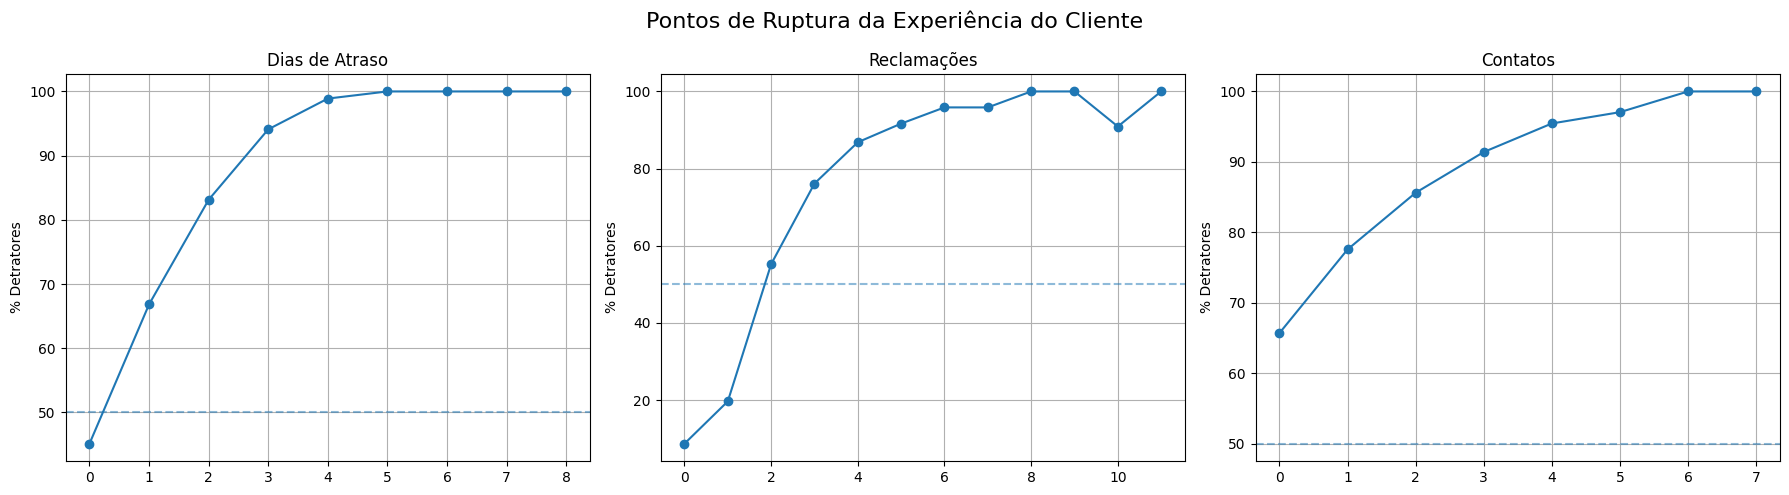

In [ ]:
# Analisando a relação entre as variáveis e o percentual de detratores

fig, axs = plt.subplots(1, 3, figsize=(18,5))


variaveis = [
    ("delivery_delay_days", "Dias de Atraso"),
    ("complaints_count", "Reclamações"),
    ("customer_service_contacts", "Contatos")
]

for ax, (col, titulo) in zip(axs, variaveis):

    dados = (
        df_nps.groupby(col)["nps_classification"]
          .apply(lambda x: (x == "Detrator").mean() * 100)
          .reset_index(name="pct")
    )

    ax.plot(
        dados[col],
        dados["pct"],
        marker="o"
    )

    ax.axhline(
        50,
        linestyle="--",
        alpha=0.5
    )

    ax.set_title(titulo)
    ax.set_ylabel("% Detratores")
    ax.grid(True)

plt.suptitle(
    "Pontos de Ruptura da Experiência do Cliente",
    fontsize=16
)

plt.tight_layout()
plt.show()